# Agent Supervisor

![](https://d.pr/i/gKezSO+)

In [1]:
%pip install -Uqqq langchain-experimental

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')


### 도구 생성

In [3]:
from langchain_tavily import TavilySearch
from langchain_experimental.tools import PythonREPLTool # 파이썬 코드 실행 Tool

tavily_tool = TavilySearch(max_results=3)
python_repl_tool = PythonREPLTool()


C:\Users\lsm15\AppData\Local\Temp\ipykernel_22812\661376187.py:2: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools import PythonREPLTool # 파이썬 코드 실행 Tool


In [4]:
# 에이전트 노드 실행기 : 각 에이전트 답변을 사람메시지로 재가공하는 헬퍼 함수
from langchain_core.messages import HumanMessage
# 에이전트를 실행하고, 마지막 ai 응답을 HumanMessage로 감싸 반환하는 함수
def agent_node(state, agent, name):
    response = agent.invoke(state)
    # 마지막 응답은 지정된 name의 HumanMessage 형태로 반환
    return {'messages': [HumanMessage(content=response['messages'][-1].content, name=name)]}

## Supervisor Agent 구성
- 다음 작업자 (Researcher / Coder / FINISH) 결정

In [5]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder # 중간 대화 삽입
from langchain.chat_models import init_chat_model
from pydantic import BaseModel # 구조화 출력
from typing import Literal # 값 제한

llm = init_chat_model('gpt-5.4-mini')
members = ['Researcher','Coder'] # 하위 에이전트
system_prompt = """  # Supervisor 역할/지침(system) 프롬프트
다음 작업자들 간의 대화를 관리하는 관리자로서 당신은 다음 작업을 수행해야 합니다: {members}.

아래의 사용자 요청을 참고하여, 다음 작업을 수행할 작업자를 지정하세요.
각 작업자는 작업을 수행하고 그 결과와 상태를 보고할 것입니다.
모든 작업이 완료되면 FINISH로 응답하세요."
"""

options = members + ['FINISH']

class RouteResponse(BaseModel):
    next: Literal["FINISH","Researcher","Coder"]

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    MessagesPlaceholder(variable_name='messages'),
    ('system', '''
위 대화를 참고하여, 누가 다음으로 행동해야 하나요? 아니면 작업을 FINISH 해야 하나요?
다음중 하나를 선택하세요: {options}
''')
]).partial(options=options, members=', '.join(members)) # partial : options/members 미리 고정

# 현재까지의 대화내용을 확인하여 다음 작업자를 라우팅해주는 Supervisor 함수
def supervisor_agent(state):
    # 프롬프트 + LLM의 응답을 RouteResponse 파싱
    supervisor_chain = prompt | llm.with_structured_output(RouteResponse)
    return supervisor_chain.invoke(state) # next값 반환

### Graph 조립

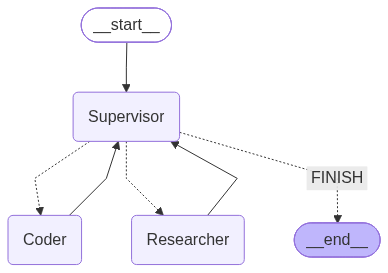

In [6]:
from typing import TypedDict, Annotated, List      # 상태 타입 정의
from langgraph.graph import StateGraph, START, END # Langgraph 구성요소
from langgraph.graph.message import add_messages   # Messages 누적 처리 유틸
from langchain_core.messages import BaseMessage    # Messages 타입 힌트 정의
from langchain.agents import create_agent          # Tool 사용하는 에이전트
import functools # partial 사용 (값을 미리 고정)

# 그래프에서 사용할 상태 스키마 커스터마이징
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages] # messages는 add_messages의 규칙으로 누적
    next: str # Supervisor가 결정한 다음 노드

research_agent = create_agent(llm, tools=[tavily_tool])
# functools.partial() : 기존함수의 일부 인자를 미리 채운 함수를 반환
# agent_node에 agent/name을 미리 정해줌
research_node = functools.partial(agent_node, agent=research_agent, name='Researcher')

code_agent = create_agent(llm, tools=[python_repl_tool])
code_node = functools.partial(agent_node, agent=code_agent, name='Coder')

workflow = StateGraph(AgentState)

workflow.add_node('Supervisor', supervisor_agent)
workflow.add_node('Researcher', research_agent)
workflow.add_node('Coder', code_node)

workflow.add_edge(START,'Supervisor')
workflow.add_edge('Researcher','Supervisor')
workflow.add_edge('Coder','Supervisor')

conditional_map = {member: member for member in members} # {'Researcher': 'Researcher', ...}
conditional_map['FINISH'] = END

# state['next']기준에 따라 조건 분기 추가
workflow.add_conditional_edges('Supervisor', lambda state: state['next'], conditional_map)

graph = workflow.compile()
graph

In [7]:
for chunk in graph.stream({
    'members': [
        ('human','C++ Helloworld 출력하는 코드를 작성하고, 콘솔에 출력해줘!')
    ]
}):
    print(chunk)

{'Supervisor': {'next': 'FINISH'}}


In [11]:
for chunk in graph.stream({
    'messages': [
        ('human','오늘 2026년 9월 4일 기준 삼성전자 주가를 matplotlib으로 시각화해 Coder사용해서.')
    ]
}):
    print(chunk) # 노드 메시지 출력

{'Supervisor': {'next': 'Researcher'}}
{'Researcher': {'messages': [HumanMessage(content='오늘 2026년 9월 4일 기준 삼성전자 주가를 matplotlib으로 시각화해 Coder사용해서.', additional_kwargs={}, response_metadata={}, id='2ffcb0cb-0c96-47ce-845d-7158f0ce03c0'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 1296, 'total_tokens': 1352, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EKH0tao3C9n2jxGmmCe1YvCqcHnKy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06af2-6937-7da3-9dba-29364dc66594-0', tool_calls=[{'name': 'tavil

In [9]:
for chunk in graph.stream({
    'messages': [
        ('human','대한민국의 코로나 연도별 감염자 수를 검색해보고 자료를 matplotlib으로 시각화 해줘. 코드로 주지 말고 도구 사용해서 직접 그려줘')
    ]
}):
    print(chunk) # 노드 메시지 출력

{'Supervisor': {'next': 'Researcher'}}
{'Researcher': {'messages': [HumanMessage(content='대한민국의 코로나 연도별 감염자 수를 검색해보고 자료를 matplotlib으로 시각화 해줘. 코드로 주지 말고 도구 사용해서 직접 그려줘', additional_kwargs={}, response_metadata={}, id='81c677ea-3da8-40fc-894d-611a22e04705'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 1307, 'total_tokens': 1397, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EKGxOLitJBpiHgQYlIxQdKBD26kay', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06aef-1a2c-7bf1-b413-6c2019e66b91-0', tool_c